# Proyecto 4: Análisis Topológico de Agregaciones Biológicas
**Diplomado de Modelado y Simulación - Módulo de Grafos y TDA**

**Instructores:** Dr. Jesús F. Espinoza & Dra. Rosalía G. Hernández

---

Esta libreta servirá como base didáctica para el Proyecto 4. Replicaremos parte de la metodología del artículo *Topological Data Analysis of Biological Aggregation Models* (Topaz, Ziegelmeier, Halverson, 2015).

**Objetivo:** Utilizar TDA para analizar la estructura dinámica de un enjambre (*swarm*).

1.  **Simularemos** el Modelo de Vicsek (partículas que se alinean).
2.  Analizaremos su comportamiento global con un **parámetro de orden**.
3.  Aplicaremos **Homología Persistente** a lo largo del tiempo para generar un gráfico **CROCKER** (Contour Realization Of Computed k-dimensional hole Evolution in the Rips complex).

### Estructura de la Libreta

- **Parte 1:** Simulación del Modelo de Vicsek
- **Parte 2:** Análisis Clásico (Parámetros de Orden)
- **Parte 3:** Análisis Topológico (CROCKER)
- **Parte 4:** Parte Experimental e Instrucciones
  - Reto. El modelo de D'Orsogna


In [ ]:
# 1. Instalación de librerías necesarias
# Ripser: Para calcular homología persistente rápida
# Persim: Para graficar diagramas
print("Instalando librerías de TDA...")
!pip install -q ripser persim

import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams
from scipy.spatial.distance import pdist, squareform
import time

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (6, 6)
print("Bibliotecas listas.")

Instalando librerías de TDA...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.3/827.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 1.8 MB/s eta 0:00:00
Bibliotecas listas.


## Parte 1: Simulación del Modelo de Vicsek

El modelo de Vicsek describe partículas que se mueven a velocidad constante y alinean su dirección con el promedio de sus vecinos dentro de un radio $R$, más un poco de ruido.

**Ecuaciones:**
1.  **Posición:** $x_i(t+1) = x_i(t) + v_i(t+1) \Delta t$
2.  **Ángulo:** $\theta_i(t+1) = \langle \theta(t) \rangle_{R} + \text{ruido}$

Vamos a simularlo en una caja con **condiciones de frontera periódicas** (como el juego de Pac-Man: si sales por la derecha, entras por la izquierda).

In [ ]:
def simular_vicsek(N=300, L=25, v0=0.5, eta=0.1, radio=1.0, pasos=200):
    """
    Simula el modelo de Vicsek.
    Parámetros:
      N: Número de partículas
      L: Tamaño de la caja (L x L)
      v0: Velocidad de las partículas
      eta: Magnitud del ruido (perturbación aleatoria)
      radio: Radio de interacción
      pasos: Número de pasos de tiempo a simular
    Retorna:
      historia_pos: Array (pasos, N, 2) con las posiciones
      historia_vel: Array (pasos, N, 2) con las velocidades
    """
    # 1. Inicialización aleatoria
    pos = np.random.rand(N, 2) * L  # Posiciones (x, y)
    ang = np.random.rand(N) * 2 * np.pi # Ángulos aleatorios
    vel = np.zeros((N, 2))

    # Guardaremos la historia para analizarla después
    historia_pos = []
    historia_vel = []

    print(f"Iniciando simulación Vicsek (N={N}, Pasos={pasos})...")

    for t in range(pasos):
        # Guardar estado actual
        # Calculamos vector de velocidad (dx, dy) basado en el ángulo
        vel[:, 0] = v0 * np.cos(ang)
        vel[:, 1] = v0 * np.sin(ang)

        historia_pos.append(pos.copy())
        historia_vel.append(vel.copy())

        # 2. Calcular distancias entre todos los pares (matriz NxN)
        # Nota: Para hacerlo simple didácticamente, usamos distancia euclidiana directa.
        # En una simulación estricta, deberíamos considerar la distancia periódica (toro).
        distancias = squareform(pdist(pos))

        # 3. Actualizar ángulos
        ang_nuevo = np.zeros(N)
        for i in range(N):
            # Encontrar vecinos dentro del radio R (incluyéndose a sí mismo)
            vecinos = distancias[i, :] < radio

            # Promedio de senos y cosenos de los vecinos (para promediar ángulos correctamente)
            seno_prom = np.mean(np.sin(ang[vecinos]))
            coseno_prom = np.mean(np.cos(ang[vecinos]))

            # Ángulo promedio
            ang_prom = np.arctan2(seno_prom, coseno_prom)

            # Añadir ruido uniforme [-eta/2, eta/2]
            ruido = np.random.uniform(-eta/2, eta/2)
            ang_nuevo[i] = ang_prom + ruido

        ang = ang_nuevo

        # 4. Actualizar posiciones (Mover partículas)
        pos = pos + vel # dt asumimos que es 1

        # 5. Aplicar condiciones periódicas (Pac-Man)
        pos = pos % L

    return np.array(historia_pos), np.array(historia_vel)

# --- EJECUTAR SIMULACIÓN ---
# Usamos parámetros similares a la Fig 6 del artículo de Topaz et al.
datos_pos, datos_vel = simular_vicsek(N=300, L=25, v0=1.0, eta=0.5, pasos=100)
print("Simulación terminada.")

Iniciando simulación Vicsek (N=300, Pasos=100)...
Simulación terminada.


Visualicemos la simulación en distintos tiempos

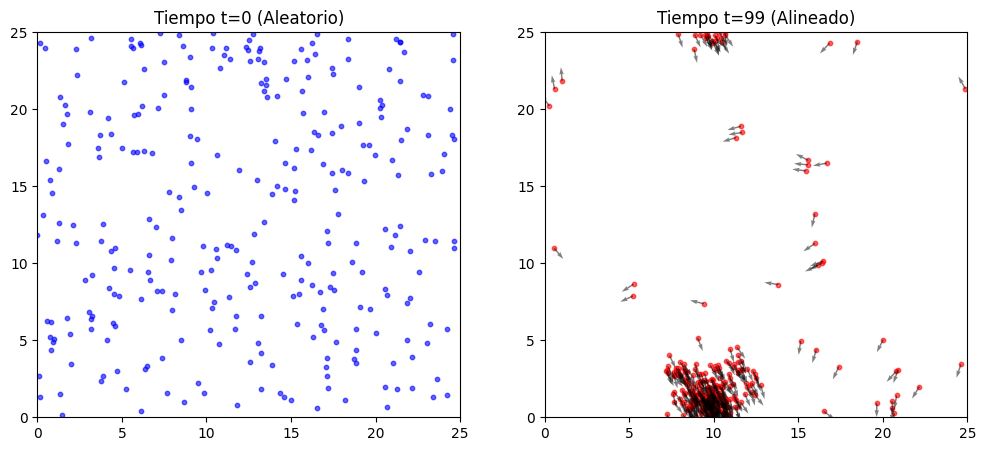

In [ ]:
# Visualicemos el estado inicial y final
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Inicio
ax[0].scatter(datos_pos[0, :, 0], datos_pos[0, :, 1], s=10, c='blue', alpha=0.6)
ax[0].set_title("Tiempo t=0 (Aleatorio)")
ax[0].set_xlim(0, 25); ax[0].set_ylim(0, 25)

# Final
ax[1].scatter(datos_pos[-1, :, 0], datos_pos[-1, :, 1], s=10, c='red', alpha=0.6)
# Dibujamos unas flechitas para ver la dirección en el final
ax[1].quiver(datos_pos[-1, :, 0], datos_pos[-1, :, 1],
             datos_vel[-1, :, 0], datos_vel[-1, :, 1], scale=30, alpha=0.5)
ax[1].set_title(f"Tiempo t={len(datos_pos)-1} (Alineado)")
ax[1].set_xlim(0, 25); ax[1].set_ylim(0, 25)

plt.show()

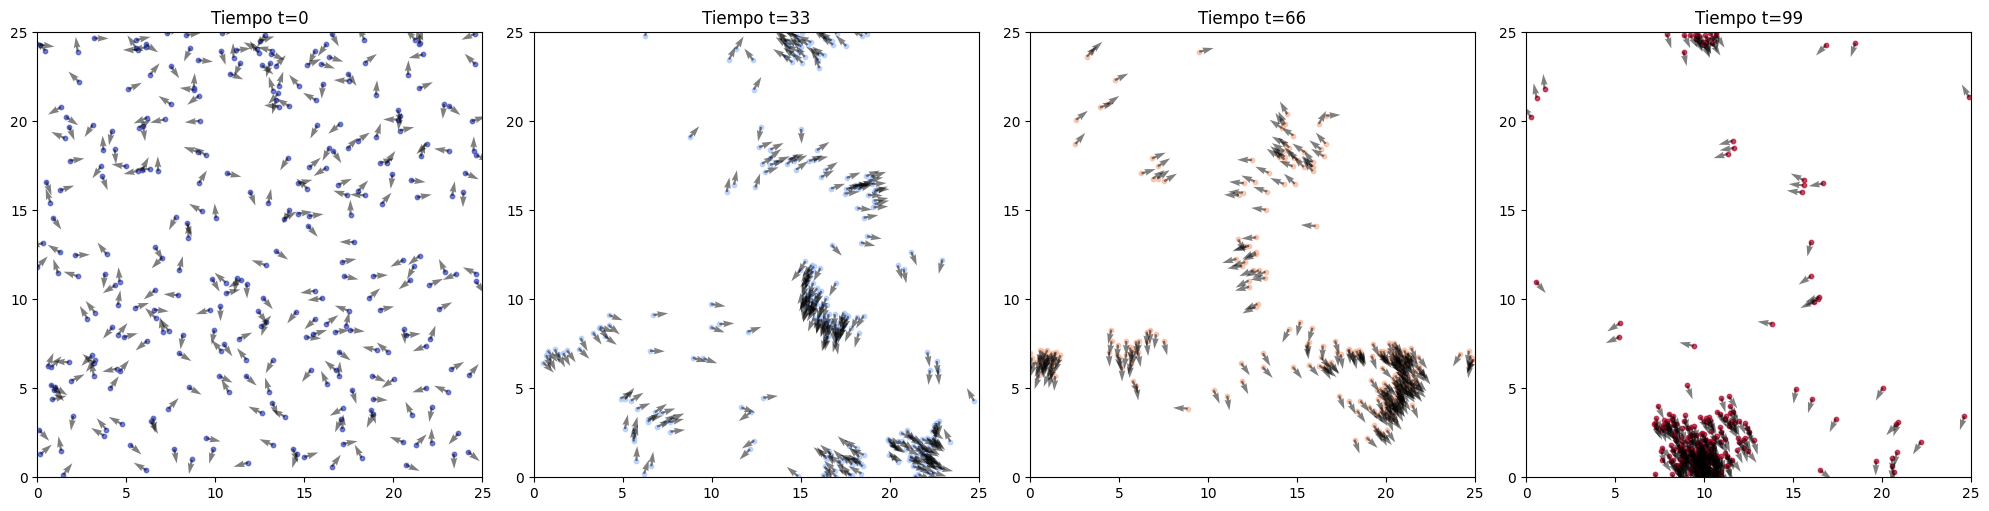

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Seleccionamos 4 índices de tiempo equidistantes (ej: 0, 33, 66, 99)
tiempos_a_graficar = np.linspace(0, len(datos_pos)-1, 4, dtype=int)

# Creamos la figura con 4 subgráficas (1 fila, 4 columnas)
# Aumentamos el ancho de la figura (figsize) para que se vean bien
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

for i, t in enumerate(tiempos_a_graficar):
    # Extraer datos del tiempo 't'
    x = datos_pos[t, :, 0]
    y = datos_pos[t, :, 1]
    u = datos_vel[t, :, 0]
    v = datos_vel[t, :, 1]

    # Scatter plot (puntos)
    # Usamos un color que cambia progresivamente de azul a rojo
    color = plt.cm.coolwarm(i / 3)
    ax[i].scatter(x, y, s=10, color=color, alpha=0.7)

    # Quiver (flechas de dirección)
    # Las añadimos en TODOS los pasos para ver cómo surge el orden
    ax[i].quiver(x, y, u, v, scale=30, alpha=0.5, width=0.005)

    # Configuración de cada panel
    ax[i].set_title(f"Tiempo t={t}")
    ax[i].set_xlim(0, 25)
    ax[i].set_ylim(0, 25)
    ax[i].set_aspect('equal') # Mantiene la proporción cuadrada de la caja

plt.tight_layout()
plt.show()

## Parte 2: Análisis Clásico (Parámetro de Orden)

En física, para saber si el grupo está alineado, se usa la **Polarización** ($\varphi$).
Es el promedio de los vectores velocidad normalizado.
* $\varphi \approx 0$: Desorden total (cada quien va por su lado).
* $\varphi \approx 1$: Orden total (todos se mueven en la misma dirección).

$$\varphi(t) = \frac{1}{N v_0} \left| \sum_{i=1}^{N} v_i(t) \right|$$

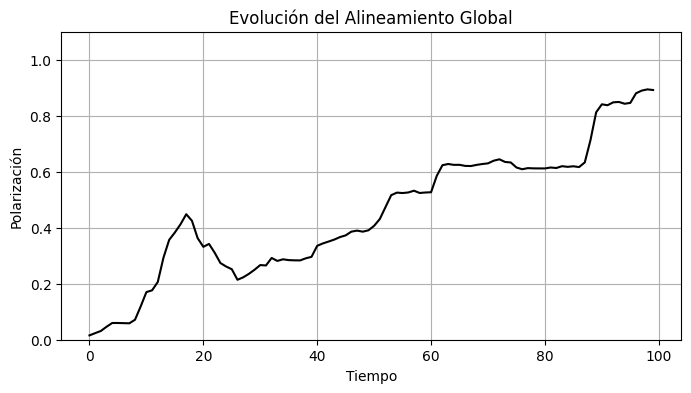

In [ ]:
def calcular_polarizacion(velocidades):
    """Calcula la polarización para cada paso de tiempo."""
    pasos = velocidades.shape[0]
    polarizacion = []

    for t in range(pasos):
        vel_t = velocidades[t] # Velocidades en tiempo t
        # Suma vectorial de todas las velocidades
        suma_vectorial = np.sum(vel_t, axis=0)
        # Magnitud de la suma
        magnitud = np.linalg.norm(suma_vectorial)
        # Normalizar (promedio)
        N = vel_t.shape[0]
        # Como v0 puede variar o no, normalizamos por la suma de normas individuales
        suma_magnitudes = np.sum(np.linalg.norm(vel_t, axis=1))

        p = magnitud / suma_magnitudes
        polarizacion.append(p)

    return polarizacion

pol = calcular_polarizacion(datos_vel)

plt.figure(figsize=(8, 4))
plt.plot(pol, color='black')
plt.xlabel("Tiempo")
plt.ylabel("Polarización")
plt.title("Evolución del Alineamiento Global")
plt.ylim(0, 1.1)
plt.grid(True)
plt.show()

## Parte 3: Análisis Topológico (CROCKER)

El parámetro de orden nos dice **cuánto** se alinean, pero no nos dice la **forma** del grupo (¿forman un solo grupo? ¿dos grupos chocando? ¿un anillo?).

Aquí entra el TDA. El artículo propone el **CROCKER Plot**, que visualiza cómo cambian los números de Betti (beta 0, beta 1) en función de dos variables:
1.  **Tiempo de simulación (t):** Eje X.
2.  **Parámetro de proximidad (epsilon):** Eje Y (la escala a la que conectamos los puntos).

**Interpretación:**
* Si vemos una "mancha" consistente en el gráfico de **Beta 0**, significa que cierto número de clústeres (componentes) persiste en el tiempo.
* Si vemos actividad en **Beta 1**, significa que hay formación de ciclos (agujeros).

*Nota: Calcularemos esto solo para los primeros 50 pasos para ahorrar tiempo de cómputo en clase.*

Calculando Homología Persistente paso a paso (esto puede tardar unos segundos)...
Cálculo terminado.


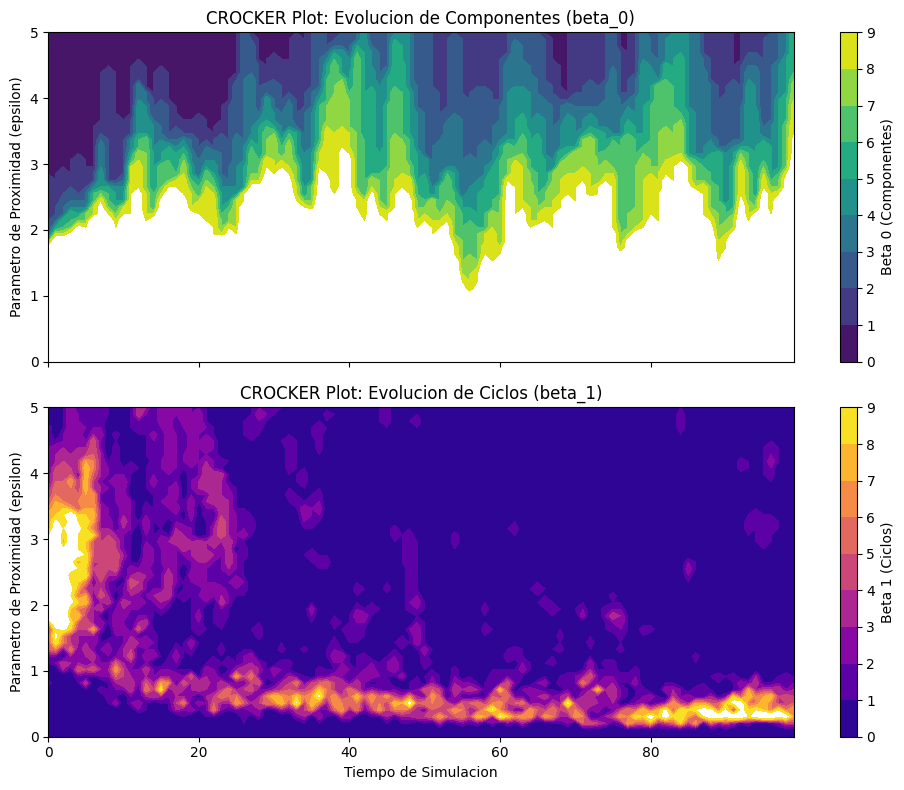

In [ ]:
# --- CÁLCULO DE CROCKER ---

# Parámetros para el análisis
pasos_analisis = 100   # Analizar solo los primeros 100 cuadros
max_epsilon = 5.0     # Escala máxima de filtración
resolucion_eps = 50   # Resolución del eje Y

# Matrices para guardar los Números de Betti
# Eje X: Tiempo, Eje Y: Epsilon
# Usamos matrices llenas de ceros inicialmente
betti_0_matriz = np.zeros((resolucion_eps, pasos_analisis))
betti_1_matriz = np.zeros((resolucion_eps, pasos_analisis))

# Definimos los valores de epsilon que vamos a "escanear" (Eje Y)
epsilons = np.linspace(0, max_epsilon, resolucion_eps)

print("Calculando Homología Persistente paso a paso (esto puede tardar unos segundos)...")

for t in range(pasos_analisis):
    # 1. Obtener la nube de puntos en el tiempo t
    nube_puntos = datos_pos[t]

    # 2. Calcular persistencia con Ripser
    # maxdim=1 para obtener H0 y H1
    # thresh=max_epsilon para no calcular más allá de lo necesario (ahorra tiempo)
    diagramas = ripser(nube_puntos, maxdim=1, thresh=max_epsilon)['dgms']

    # 3. "Vectorizar" el diagrama para el CROCKER
    # Para cada valor de epsilon en nuestro eje Y, contamos cuántas barras están "vivas"
    for i, eps in enumerate(epsilons):
        # --- Para H0 (Componentes Conexas) ---
        dgm0 = diagramas[0]
        # Contar barras que nacieron antes de eps y mueren después de eps
        # Nota: en H0, nacen en 0. Solo checamos muerte > eps.
        # Las barras infinitas se consideran vivas.
        vivos_b0 = np.sum((dgm0[:, 0] <= eps) & (dgm0[:, 1] > eps))
        betti_0_matriz[i, t] = vivos_b0

        # --- Para H1 (Ciclos/Bucles) ---
        if len(diagramas) > 1:
            dgm1 = diagramas[1]
            vivos_b1 = np.sum((dgm1[:, 0] <= eps) & (dgm1[:, 1] > eps))
            betti_1_matriz[i, t] = vivos_b1

print("Cálculo terminado.")

# --- VISUALIZACIÓN (CROCKER PLOT) ---
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico para Beta 0 (Componentes Conexas)
# Usamos contourf (mapa de contornos lleno)
# Niveles discretos para ver 1, 2, 3... componentes
niveles = np.arange(0, 10, 1)
c1 = ax[0].contourf(range(pasos_analisis), epsilons, betti_0_matriz, levels=niveles, cmap='viridis')
plt.colorbar(c1, ax=ax[0], label='Beta 0 (Componentes)')
ax[0].set_ylabel('Parametro de Proximidad (epsilon)')
ax[0].set_title('CROCKER Plot: Evolucion de Componentes (beta_0)')

# Gráfico para Beta 1 (Ciclos)
c2 = ax[1].contourf(range(pasos_analisis), epsilons, betti_1_matriz, levels=niveles, cmap='plasma')
plt.colorbar(c2, ax=ax[1], label='Beta 1 (Ciclos)')
ax[1].set_ylabel('Parametro de Proximidad (epsilon)')
ax[1].set_xlabel('Tiempo de Simulacion')
ax[1].set_title('CROCKER Plot: Evolucion de Ciclos (beta_1)')

plt.tight_layout()
plt.show()

<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:44: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:44: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-4141106842.py:27: SyntaxWarning: invalid escape sequence '\e'
  ax[0].set_ylabel('Parámetro de Proximidad ($\epsilon$)')
/tmp/ipython-input-4141106842.py:44: SyntaxWarning: invalid escape sequence '\e'
  ax[1].set_ylabel('Parámetro de Proximidad ($\epsilon$)')


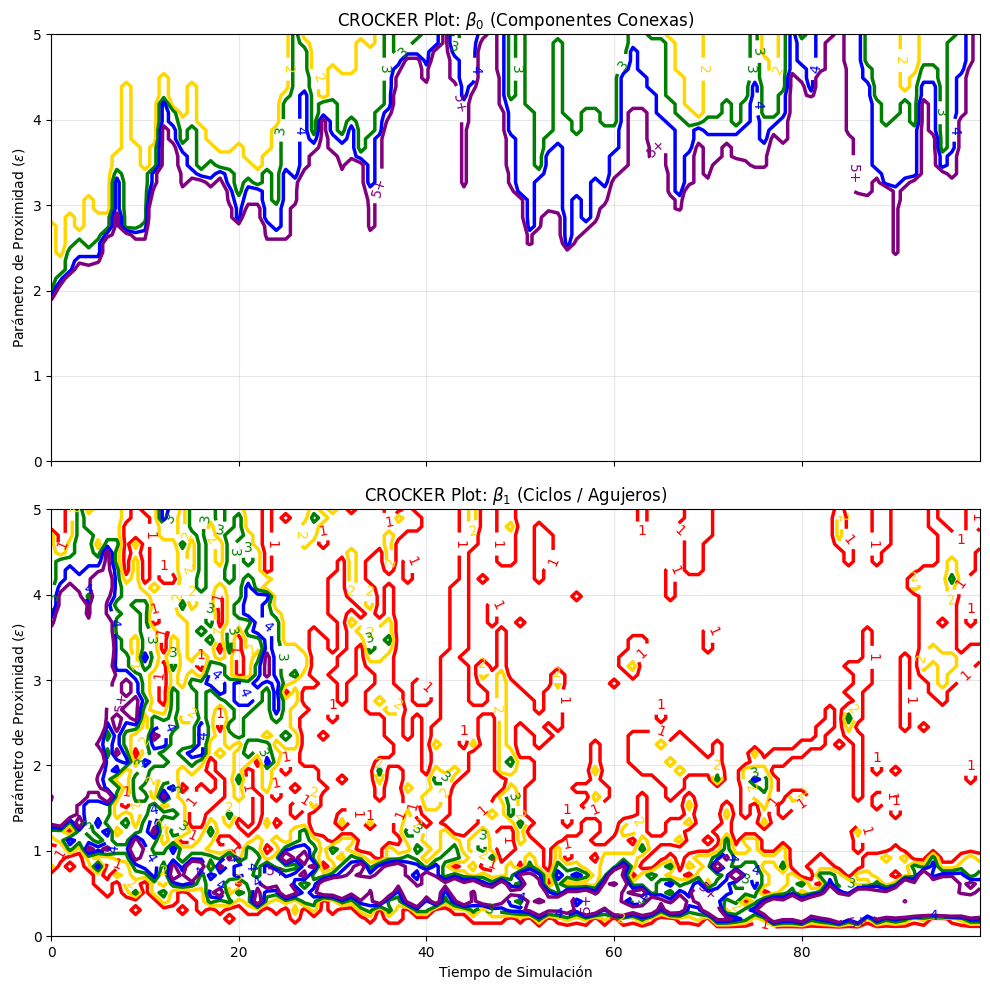

In [ ]:
# --- VISUALIZACIÓN ESTILO PAPER (CROCKER) ---
import matplotlib.colors as mcolors

fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# 1. Definir niveles discretos y colores manuales estilo "Paper"
# El paper agrupa todo lo que sea >= 5 como ruido.
# Asignamos colores específicos a los valores bajos de Betti.
niveles = [0.5, 1.5, 2.5, 3.5, 4.5]
# Nota: Los contornos se dibujan ENTRE valores.
# 0.5 separa 0 de 1. 1.5 separa 1 de 2, etc.

# Colores aproximados al paper (Fig 6):
# Betti 0: Rojo (o ausencia), Betti 1: Amarillo, Betti 2: Verde...
colores_custom = ['red', 'gold', 'green', 'blue', 'purple']

# ==========================================
# Gráfico Superior: Beta 0 (Componentes)
# ==========================================
# Usamos 'contour' (lineas) en vez de 'contourf' (relleno)
CS0 = ax[0].contour(range(pasos_analisis), epsilons, betti_0_matriz,
                    levels=niveles,
                    colors=colores_custom,
                    linewidths=2.5)

ax[0].clabel(CS0, inline=True, fontsize=10, fmt={0.5:'1', 1.5:'2', 2.5:'3', 3.5:'4', 4.5:'5+'})
ax[0].set_ylabel('Parámetro de Proximidad ($\epsilon$)')
ax[0].set_title('CROCKER Plot: $\\beta_0$ (Componentes Conexas)')
ax[0].grid(True, alpha=0.3)

# Interpretación visual similar al paper:
# La línea AMARILLA suele marcar la transición a 1 sola componente (el grupo unido).
# Todo lo que está ARRIBA de la línea amarilla es el "estado conectado".

# ==========================================
# Gráfico Inferior: Beta 1 (Ciclos)
# ==========================================
CS1 = ax[1].contour(range(pasos_analisis), epsilons, betti_1_matriz,
                    levels=niveles,
                    colors=colores_custom,
                    linewidths=2.5)

ax[1].clabel(CS1, inline=True, fontsize=10, fmt={0.5:'1', 1.5:'2', 2.5:'3', 3.5:'4', 4.5:'5+'})
ax[1].set_ylabel('Parámetro de Proximidad ($\epsilon$)')
ax[1].set_xlabel('Tiempo de Simulación')
ax[1].set_title('CROCKER Plot: $\\beta_1$ (Ciclos / Agujeros)')
ax[1].grid(True, alpha=0.3)

# Interpretación visual similar al paper:
# Las regiones encerradas por líneas ROJAS indican ausencia de ciclos (b1=0).
# Las regiones encerradas por líneas AMARILLAS indican 1 ciclo persistente.

plt.tight_layout()
plt.show()

## Proyecto 4: El Reto (Modelo de D'Orsogna)

El equipo asignado a este proyecto deberá modificar esta libreta para replicar los resultados de la **Figura 12** del artículo.

**Instrucciones para el Equipo:**

1.  **Modificar la física:** Reemplazar la función `simular_vicsek` por una función `simular_dorsogna`.
    * Vicsek es de primer orden (velocidad constante, cambia dirección).
    * D'Orsogna es de segundo orden (como las leyes de Newton: Fuerza = masa * aceleración).
    * Necesitarán implementar las fuerzas de **atracción-repulsión** (potencial de Morse) descritas en la ecuación (11) del paper.

2.  **Buscar el "Molino" (Mill):**
    * El paper muestra que el modelo de D'Orsogna forma estructuras de anillo (mills).
    * Su objetivo es encontrar parámetros donde se forme un anillo (o doble anillo).

3.  **Analizar con TDA:**
    * Usar el código de CROCKER de arriba.
    * **Hipótesis:** Si se forma un molino (anillo rotatorio), ¿qué deberían ver en el gráfico de Beta 1 (Ciclos)? Deberían ver una franja persistente indicando Beta 1 = 1 (o 2 para un doble molino).

**¡Manos a la obra!**